# Load training data

In [15]:
from pathlib import Path
import pandas as pd
#load metadata
#data can be downloaded from https://huggingface.co/datasets/imageomics/sentinel-beetles
root = Path("/home/seiso/.cache/huggingface/hub/datasets--imageomics--sentinel-beetles/snapshots/936be0d15bc051ea751d6d081d2bc44294988950")
train_df = pd.read_csv(root  / "train.csv")
val_df = pd.read_csv(root / "val.csv")
#combine all train data(training and validation set)
df = pd.concat([train_df, val_df], ignore_index=True)
#display example of data structure
df.head()

,SPEI_1y,SPEI_2y,SPEI_30d,public_id,eventID,domainID,scientificName,siteID,collectDate,relative_img_loc,colorpicker_path,scalebar_path
0,-0.710,-0.572,0.552,854913723,727,46,Carabus goryi,8,2017-07-11,854913723.png,colorpicker_1672529627.png,scalebar_1672529627.png
1,1.690,2.090,0.074,347472321,203,3,Pterostichus coracinus,24,2019-08-29,347472321.png,colorpicker_168205273.png,scalebar_168205273.png
2,1.450,1.010,1.442,2978263291,122,3,Chlaenius aestivus,2,2018-07-03,2978263291.png,colorpicker_2862281417.png,scalebar_2862281417.png
3,-0.900,-0.710,-0.390,1290955733,1404,202,Pasimachus elongatus,30,2018-06-14,1290955733.png,colorpicker_2115179197.png,scalebar_2115179197.png
4,0.668,1.130,0.168,3303810999,777,46,Carabus goryi,8,2022-06-21,3303810999.png,colorpicker_1758976511.png,scalebar_1758976511.png


# Understand size of data

In [16]:
print(f'Total number of images: {len(df)}')
print(f'Total number of domains in training data: {df['domainID'].nunique()}')
print(f'Total number of events in training data: {df['eventID'].nunique()}')

Total number of images: 24856
Total number of domains in training data: 10
Total number of events in training data: 1096


# Understand range of data

In [17]:
#SPEI_30d
print(f'SPEI_30 min value of {df['SPEI_30d'].min()} and max value of {df['SPEI_30d'].max()} with a mean of {df['SPEI_30d'].mean()} and std of {df['SPEI_30d'].std()}')
#SPEI_1y
print(f'SPEI_1y min value of {df['SPEI_1y'].min()} and max value of {df['SPEI_1y'].max()} with a mean of {df['SPEI_1y'].mean()} and std of {df['SPEI_1y'].std()}')
#SPEI_2y
print(f'SPEI_2y min value of {df['SPEI_2y'].min()} and max value of {df['SPEI_2y'].max()} with a mean of {df['SPEI_2y'].mean()} and std of {df['SPEI_2y'].std()} \n')

#range of collection date

#make sure collectDate is in date format
df['collectDate'] = pd.to_datetime(df['collectDate'], format='mixed')

print(f'first collection date: {df['collectDate'].min()}')
print(f'last collection date: {df['collectDate'].max()}')

SPEI_30 min value of -2.08999991416931 and max value of 2.08999991416931 with a mean of 0.13572709470827554 and std of 0.9961533655985543
SPEI_1y min value of -2.08999991416931 and max value of 2.08999991416931 with a mean of 0.450790386702065 and std of 1.0558856185910515
SPEI_2y min value of -2.08999991416931 and max value of 2.08999991416931 with a mean of 0.5450287278920396 and std of 1.1124685586426921 

first collection date: 2014-06-03 00:00:00
last collection date: 2023-10-11 00:00:00


# Visualize data

Text(0.5, 1.0, 'Number of images per site, colored by domain')

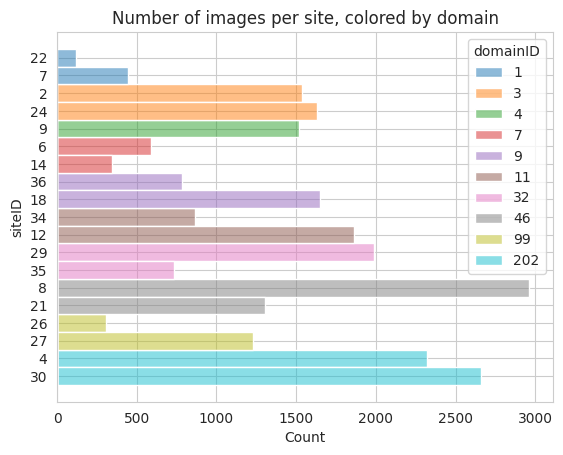

In [18]:
#visualize sites and domains
import seaborn as sns

sns.set_style("whitegrid")
df = df.sort_values("domainID")
df["domainID"] = df["domainID"].astype(str)
df["siteID"] = df["siteID"].astype(str)
ax = sns.histplot(df, y = "siteID", hue = "domainID")
ax.set_title("Number of images per site, colored by domain")

/tmp/ipykernel_21914/2080895536.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


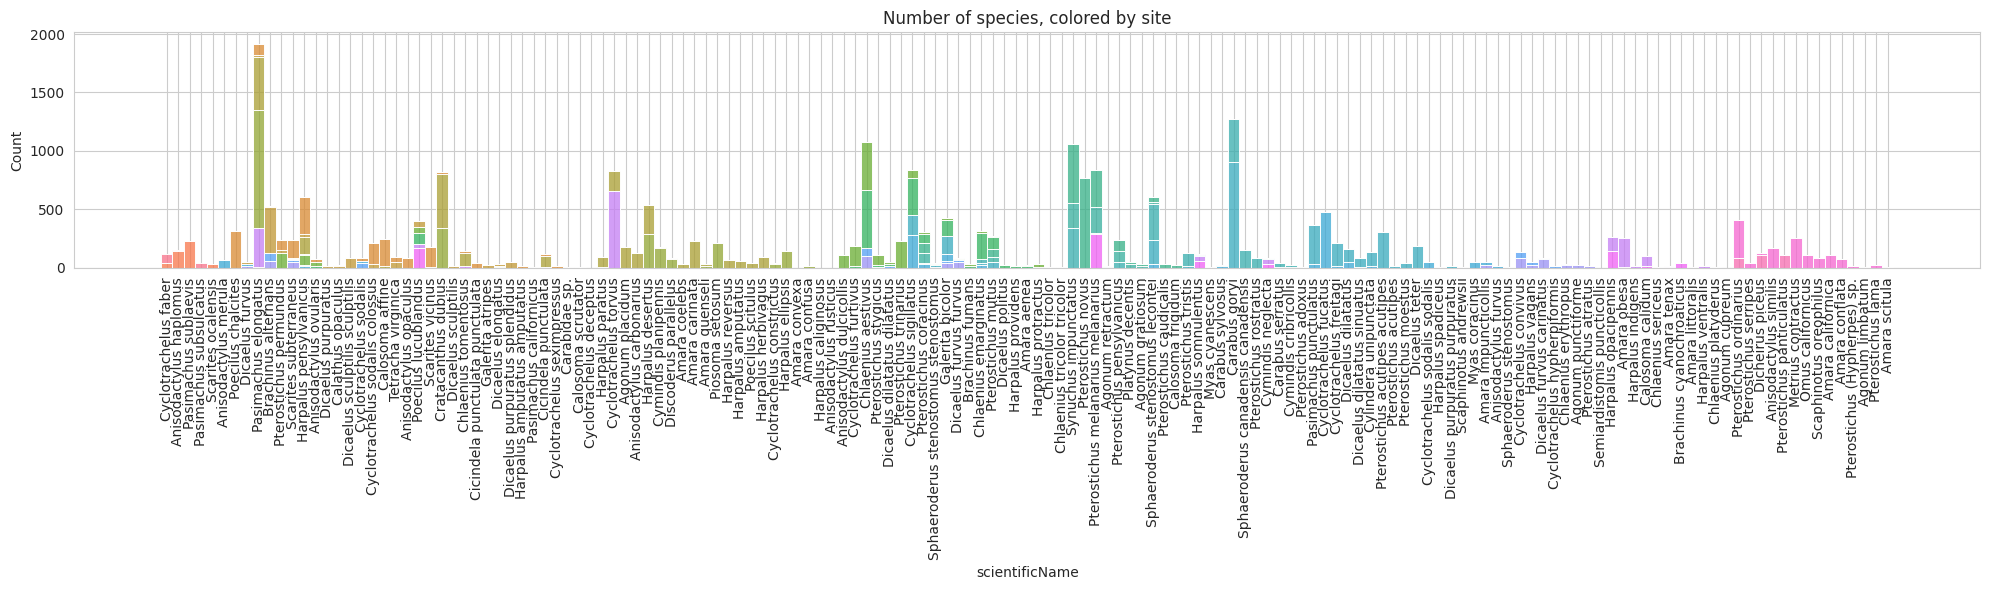

In [19]:
#visualize species
import matplotlib.pyplot as plt

df = df.sort_values("domainID")
df["domainID"] = df["domainID"].astype(str)
df["siteID"] = df["siteID"].astype(str)
plot_m = plt.figure(figsize=(20, 6))
ax = sns.histplot(df, x = "scientificName", hue = "siteID", multiple="stack")
ax.set_title("Number of species, colored by site")
ax.legend_.remove()
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.tight_layout()

Text(0.5, 1.0, 'Number of images per date, colored by domain')

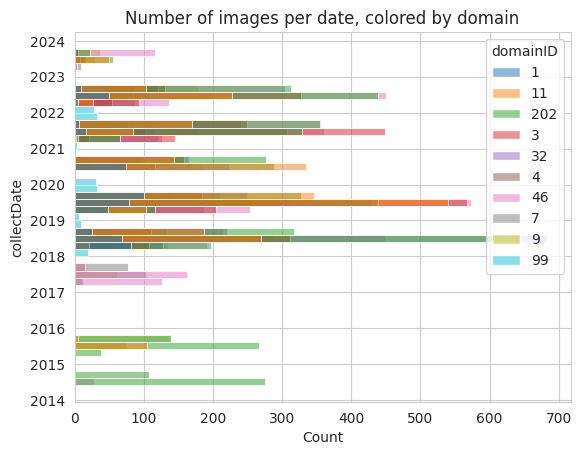

In [20]:
#visualize images per date
ax = sns.histplot(df, y="collectDate", hue="domainID")
ax.set_title("Number of images per date, colored by domain")

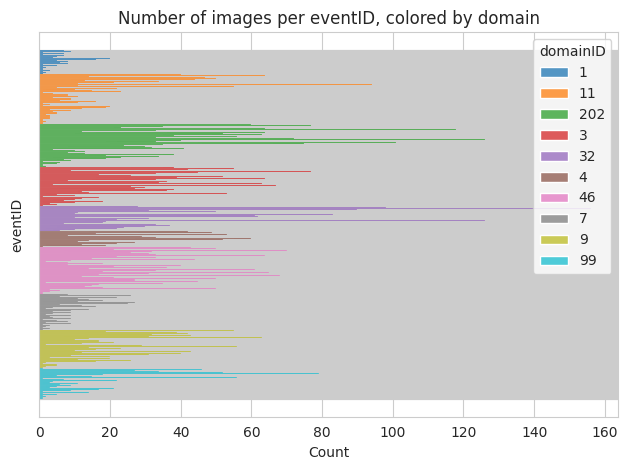

In [21]:
#visualize distribution of events per domain
df = df.sort_values("domainID")
df["domainID"] = df["domainID"].astype(str)
df["siteID"] = df["siteID"].astype(str)
df["eventID"] = df["eventID"].astype(str)
ax = sns.histplot(df, y = "eventID", hue = "domainID", multiple="stack")
ax.set_title("Number of images per eventID, colored by domain")
ax.set_yticklabels([])

plt.tight_layout()

Text(0.5, 1.0, 'SPEI_30d distribution')

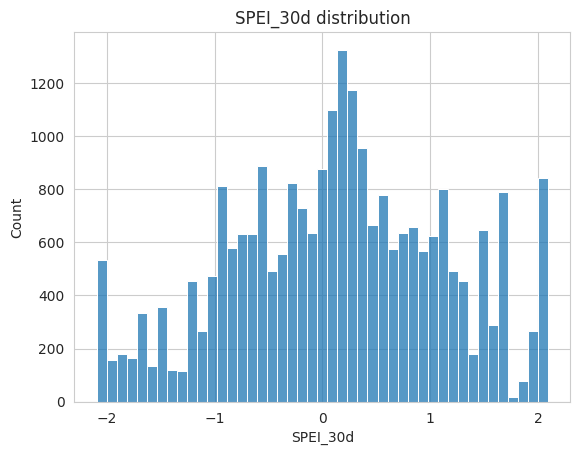

In [22]:
#overall distributions
ax = sns.histplot(df, x='SPEI_30d')
ax.set_title('SPEI_30d distribution')



Text(0.5, 1.0, 'SPEI_1yr distribution')

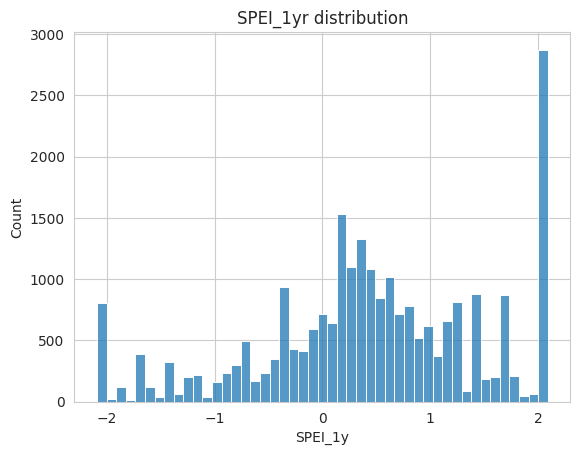

In [23]:
ax = sns.histplot(df, x='SPEI_1y')
ax.set_title('SPEI_1yr distribution')



Text(0.5, 1.0, 'SPEI_2yr distribution')

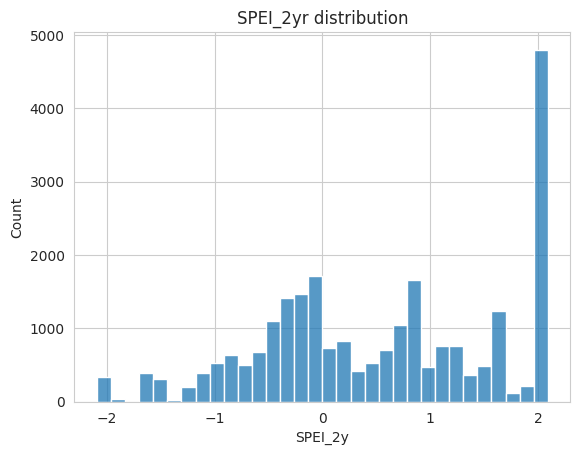

In [24]:
ax = sns.histplot(df, x='SPEI_2y')
ax.set_title('SPEI_2yr distribution')

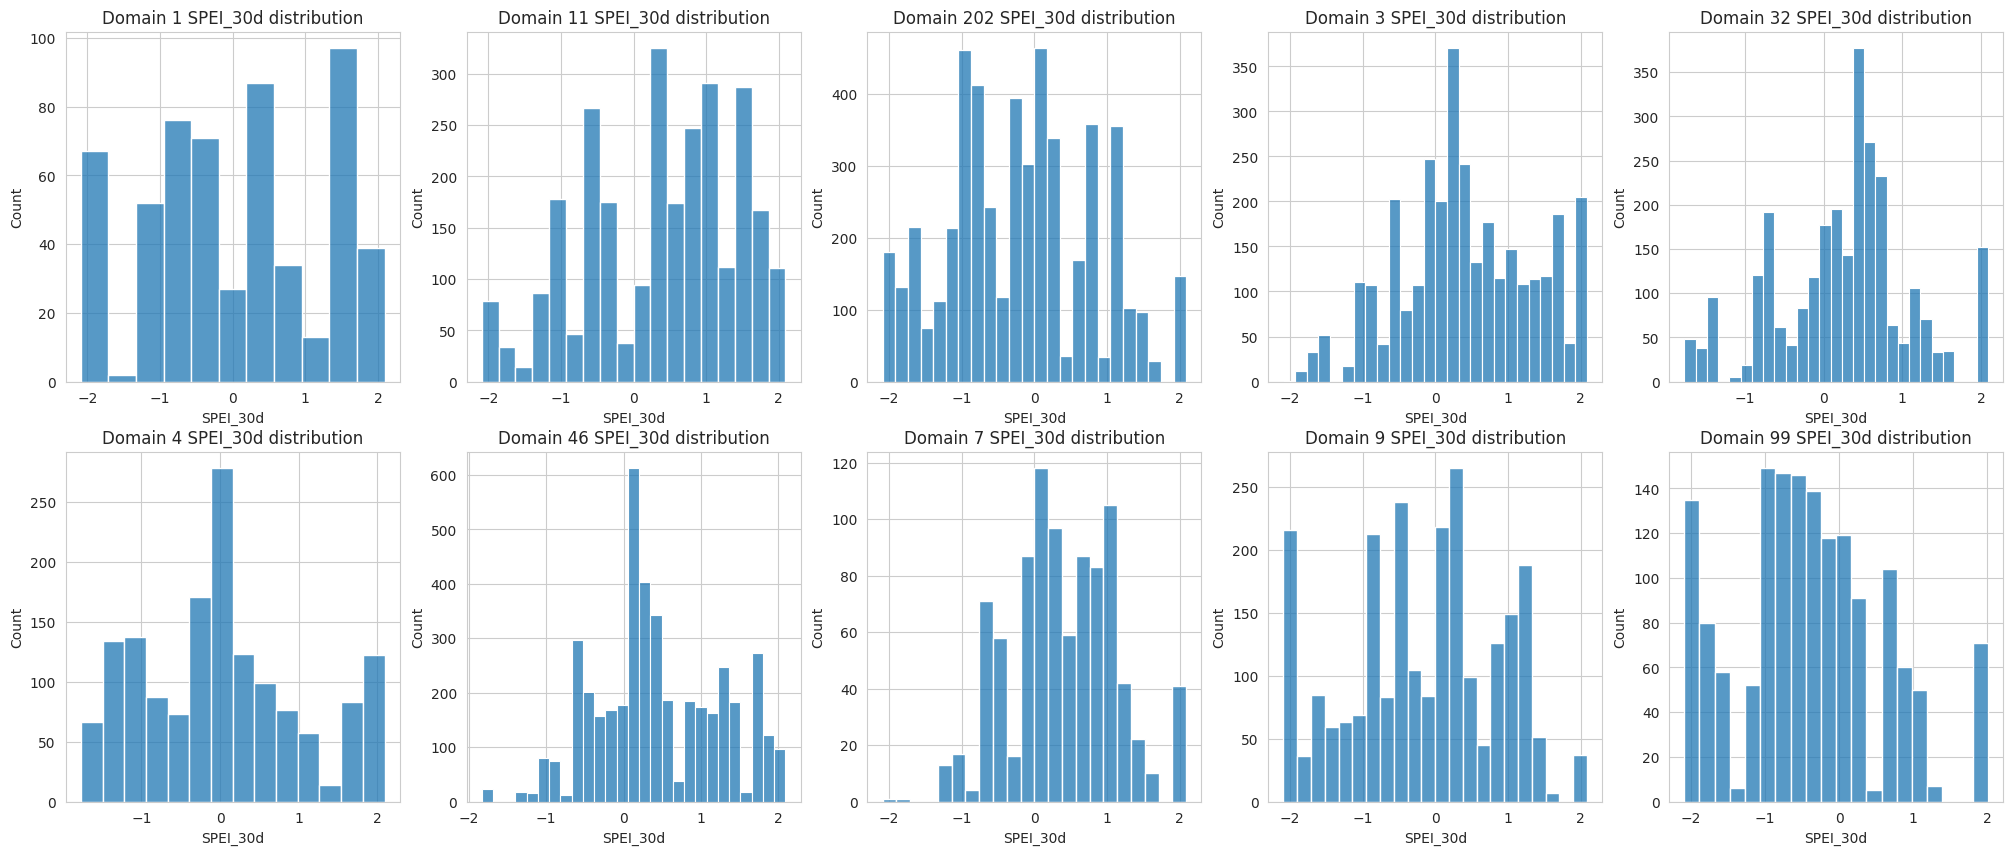

In [25]:
#30d SPEI distribution
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
domain_ids = df["domainID"].unique()
for i, domain_id in enumerate(domain_ids):
    row = i // 5
    col = i % 5
    ax = axs[row, col]
    sns.histplot(df[df['domainID'] == domain_id], x="SPEI_30d", ax=ax)
    ax.set_title(f"Domain {domain_id} SPEI_30d distribution")


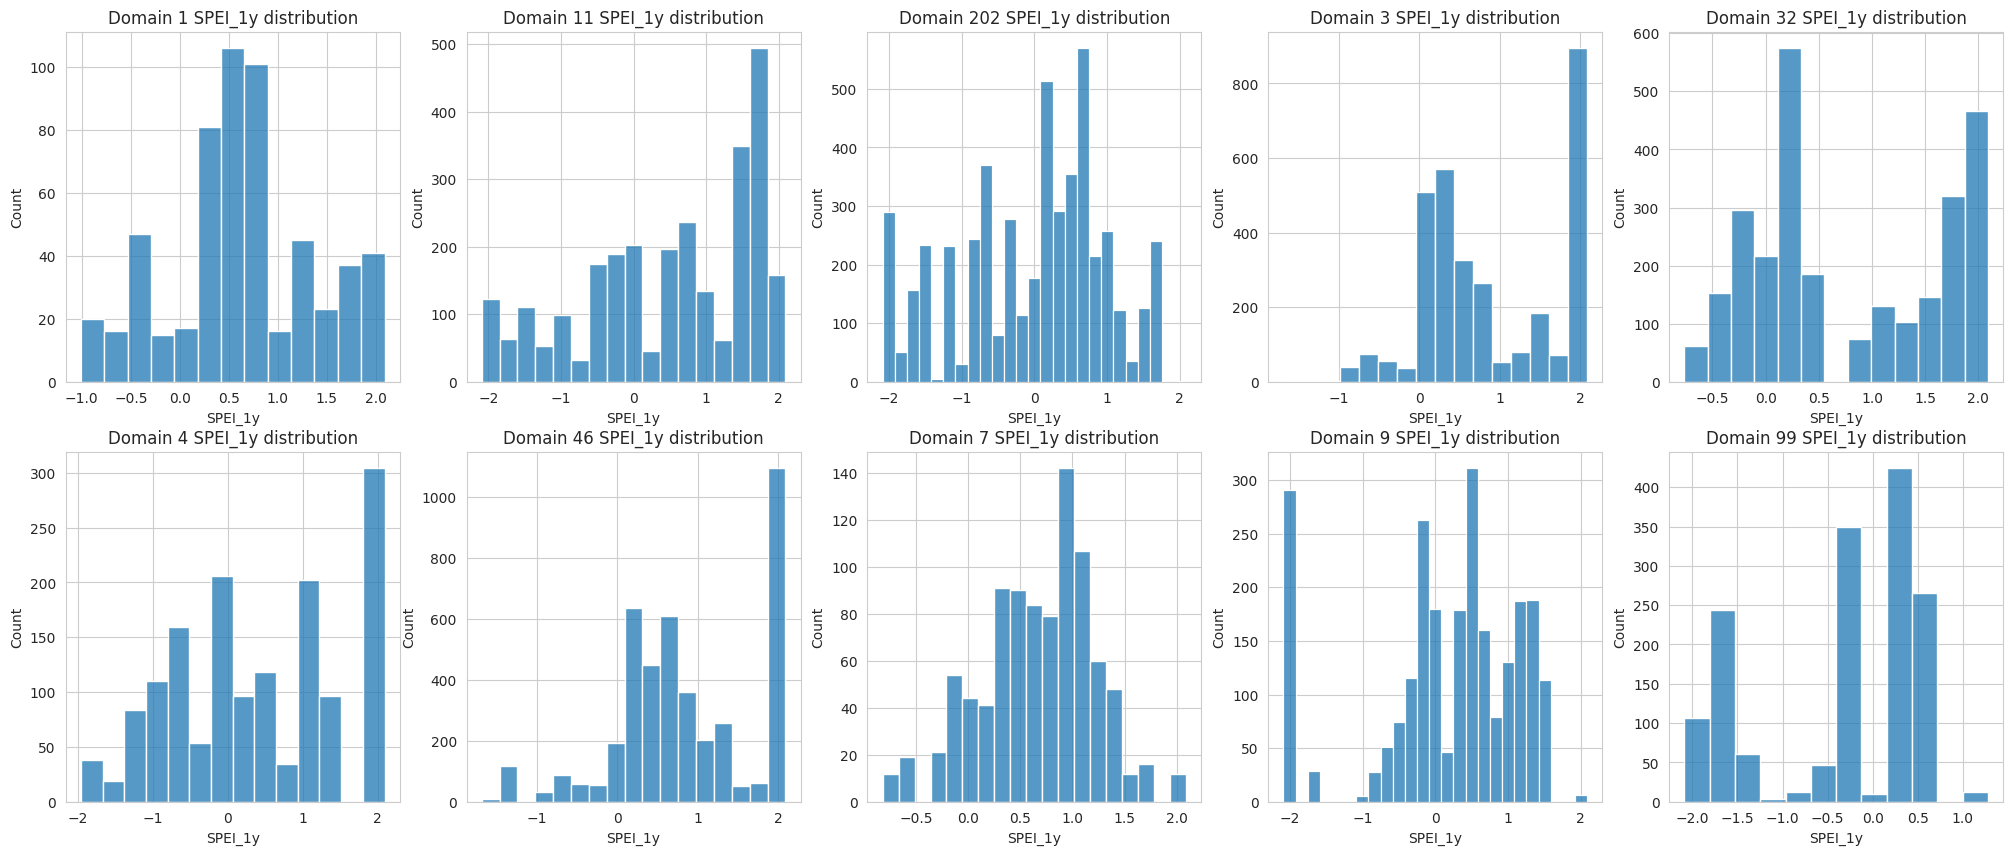

In [26]:
#1y SPEI distribution
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
domain_ids = df["domainID"].unique()
for i, domain_id in enumerate(domain_ids):
    row = i // 5
    col = i % 5
    ax = axs[row, col]
    sns.histplot(df[df['domainID'] == domain_id], x="SPEI_1y", ax=ax)
    ax.set_title(f"Domain {domain_id} SPEI_1y distribution")


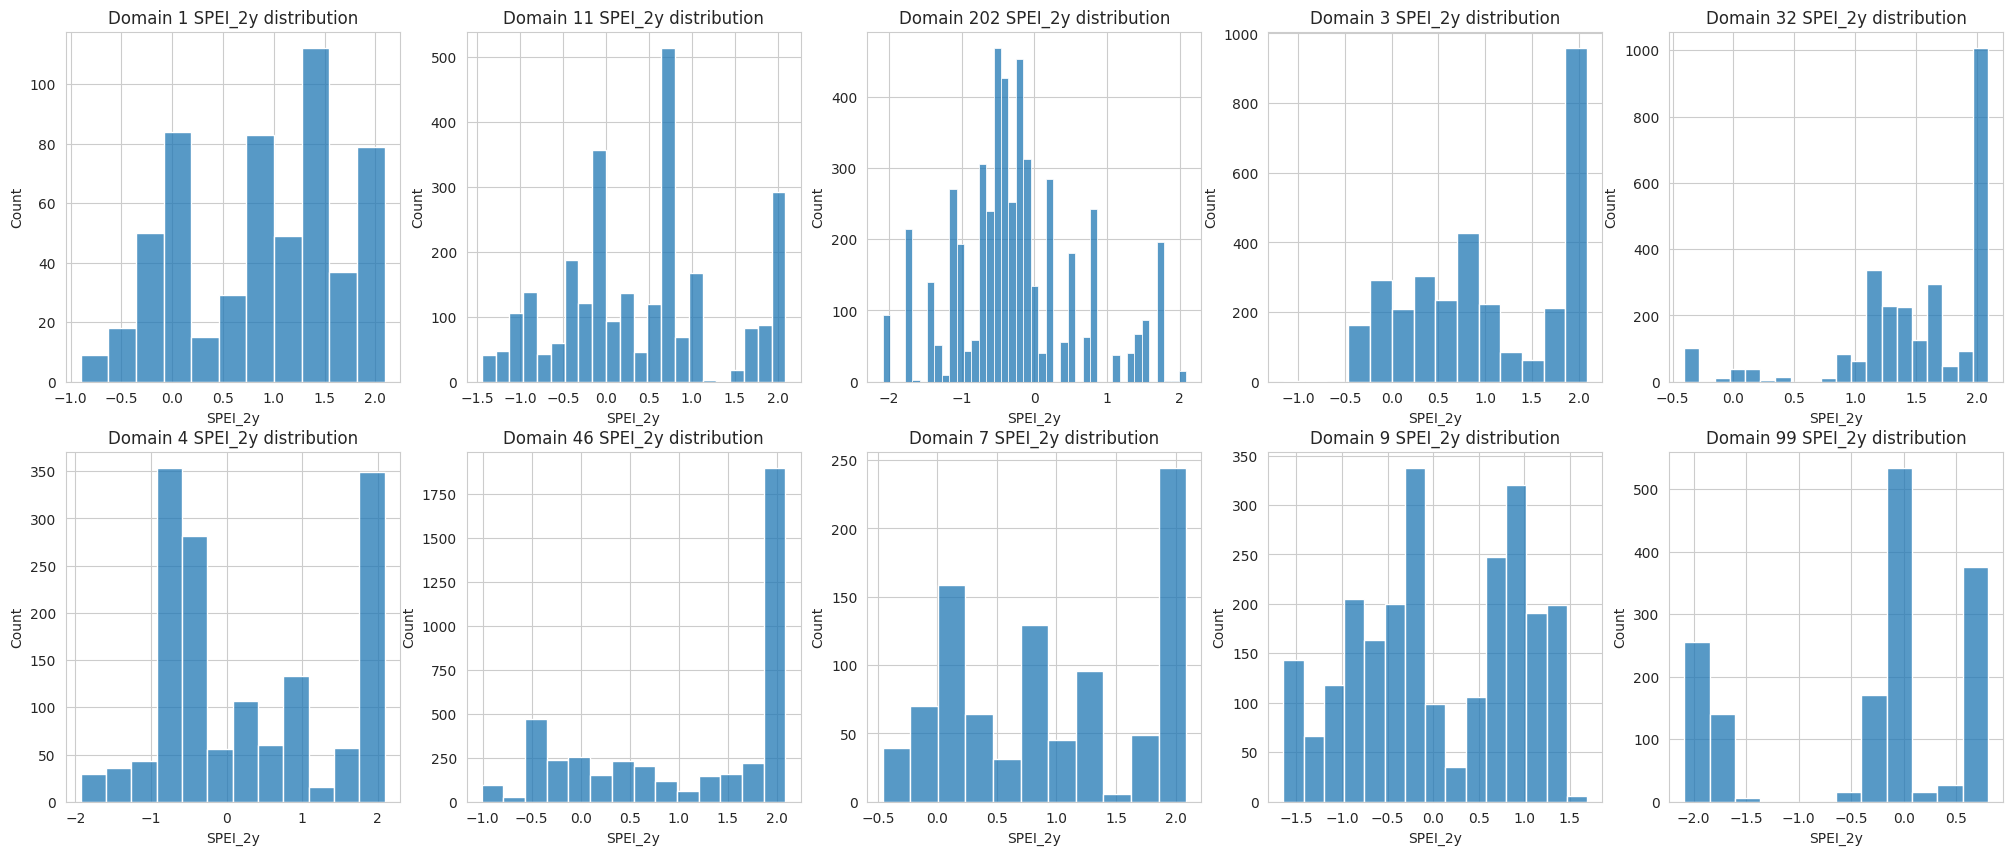

In [27]:
#2y SPEI distribution
fig, axs = plt.subplots(2, 5, figsize=(25, 10))
domain_ids = df["domainID"].unique()
for i, domain_id in enumerate(domain_ids):
    row = i // 5
    col = i % 5
    ax = axs[row, col]
    sns.histplot(df[df['domainID'] == domain_id], x="SPEI_2y", ax=ax)
    ax.set_title(f"Domain {domain_id} SPEI_2y distribution")
